# Imports and layer



In [1]:
pip install torch

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Parameter
import math
import seaborn as sns

In [4]:
goeblue = '#153268'
midblue = '#0093c7'

In [4]:
# @title
class BayesLinear(nn.Module):

    def __init__(self,
                 in_features,
                 out_features,
                 bias = True,
                 weight_prior_mu = 0.,
                 weight_prior_sigma = .1,
                 bias_prior_mu = 0.,
                 bias_prior_sigma = .1):

        super(BayesLinear, self).__init__()

        self.samples = {'weights' : None, 'bias' : None}

        self.in_features = in_features
        self.out_features = out_features
        self.bias = bias
        self.weight_prior_mu = weight_prior_mu
        self.weight_prior_sigma = weight_prior_sigma
        self.l_weight_prior_sigma = torch.log(torch.tensor(weight_prior_sigma)) # take log of the sigma prior

        self.weights_mu = Parameter(torch.rand(out_features, in_features)-0.5) #initialize mu weights maybe add the prior here
        self.lweights_sigma = Parameter(torch.log(weight_prior_sigma*torch.ones(out_features, in_features))) # intialize log weights for sigma

        if self.bias:
            self.bias_prior_mu = bias_prior_mu
            self.bias_prior_sigma = bias_prior_sigma
            self.bias_mean = Parameter(torch.rand(out_features)-0.5) # intialize bias mean if given
            self.lbias_sigma = Parameter(torch.log(bias_prior_sigma* torch.ones(out_features))) # intialize bias sigma



    def getSampledWeights(self):
        return self.samples['weights']

    def getSampledBias(self):
        return self.samples['bias']

    def kl_div(self, mu_q, sigma_q, mu_p, sigma_p):
        kl = sigma_p - sigma_q + (torch.exp(sigma_q)**2 + (mu_q - mu_p)**2) / (2 * math.exp(sigma_p)**2) - 0.5  # Kullback Leibler divergence for two normals

        return kl.mean()


    def forward(self, x):

        self.samples['weights'] = self.weights_mu + torch.exp(self.lweights_sigma) * torch.randn_like(self.lweights_sigma) #training with stochastic gradient ascent

        kl = self.kl_div(self.weights_mu, self.lweights_sigma, self.weight_prior_mu, self.l_weight_prior_sigma)

        if self.bias:

          self.samples['bias'] = self.bias_mean + torch.exp(self.lbias_sigma) * torch.randn_like(self.lbias_sigma)
          kl += self.kl_div(self.bias_mean, self.lbias_sigma, self.bias_prior_mu, self.bias_prior_sigma)


        out = F.linear(x, self.samples['weights'], self.samples['bias'] if self.bias else None) # return linear


        return out, kl

# Generate Images and Data

## Image encoder


In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, ExponentialLR, StepLR
import torchvision
from torchvision import datasets, transforms, models
import fastprogress
import pandas as pd
import time

In [ ]:
!pip install torch==1.7.1+cu110 torchvision==0.8.2+cu110 torchaudio==0.7.2  pytorch-lightning==1.2.2  torchtext==0.8.0 -f https://download.pytorch.org/whl/torch_stable.html
!pip install scipy==1.5.4
!pip install numpy==1.26.4
!pip install tqdm
!pip install pytorch-fid==0.2.0
!pip install pandas==1.1.5
!pip install lpips==0.1.4
!pip install lmdb==1.2.1
!pip install ftfy
!pip install regex
!pip install dlib requests


!git clone https://github.com/phizaz/diffae
!git pull https://github.com/phizaz/diffae



%cd 'diffae'

Looking in links: https://download.pytorch.org/whl/torch_stable.html
ERROR: Could not find a version that satisfies the requirement torch==1.7.1+cu110 (from versions: 2.2.0, 2.2.0+cpu, 2.2.0+cpu.cxx11.abi, 2.2.0+cu118, 2.2.0+cu121, 2.2.0+rocm5.6, 2.2.0+rocm5.7, 2.2.1, 2.2.1+cpu, 2.2.1+cpu.cxx11.abi, 2.2.1+cu118, 2.2.1+cu121, 2.2.1+rocm5.6, 2.2.1+rocm5.7, 2.2.2, 2.2.2+cpu, 2.2.2+cpu.cxx11.abi, 2.2.2+cu118, 2.2.2+cu121, 2.2.2+rocm5.6, 2.2.2+rocm5.7, 2.3.0, 2.3.0+cpu, 2.3.0+cpu.cxx11.abi, 2.3.0+cu118, 2.3.0+cu121, 2.3.0+rocm5.7, 2.3.0+rocm6.0, 2.3.1, 2.3.1+cpu, 2.3.1+cpu.cxx11.abi, 2.3.1+cu118, 2.3.1+cu121, 2.3.1+rocm5.7, 2.3.1+rocm6.0, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0)
ERROR: No matching distribution found for torch==1.7.1+cu110
  Using cached scipy-1.5.4.tar.gz (25.2 MB)
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error origina

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pip install lmdb
!pip install pytorch_fid
!pip install lpips
!pip install pytorch_lightning

ERROR: Could not find a version that satisfies the requirement install (from versions: none)
ERROR: No matching distribution found for install
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 64.7 MB/s eta 0:00:00


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive/')#@markdown  🔧 Import libraries and tools

import os
import os.path as osp
import matplotlib.pyplot as plt

from templates import *
from templates_cls import *
from experiment_classifier import ClsModel

def show_images(images, cols = 1, titles = None, apply_convert=False):
    if apply_convert: images = [convert(img) for img in images]
    assert((titles is None)or (len(images) == len(titles)))
    n_images = len(images)
    if titles is None: titles = ['Image (%d)' % i for i in range(1,n_images + 1)]
    fig = plt.figure()
    for n, (image, title) in enumerate(zip(images, titles)):
        a = fig.add_subplot(cols, int(np.ceil(n_images/float(cols))), n + 1)
        if image.ndim == 2:
            plt.gray()
        plt.imshow(image)
        a.set_title(title)
    fig.set_size_inches(np.array(fig.get_size_inches()) * n_images*2)
    plt.show()

def convert2rgb(img,adjust_scale=True):
    convert_img = torch.tensor(img)
    if adjust_scale: convert_img = (convert_img+1)/2
    return (convert_img).permute(1, 2, 0).cpu()

In [ ]:
device = 'cuda'
model_resolution = 256
T_inv = "200"
T_step = 100

model_config = ffhq256_autoenc() if model_resolution == 256 else  ffhq128_autoenc_130M()

print(model_config.name)


# download model weight & its inferenced latents

ffhq256_autoenc


In [ ]:
download_paths = {
    256: {
        'diffae_weight': 'https://vistec-my.sharepoint.com/:u:/g/personal/nattanatc_pro_vistec_ac_th/ER56kn-uzlNAi39E1c784qQBkj5RI7-OAZC9QghQsIDQiQ?download=1' ,
        'diffae_latent':  'https://vistec-my.sharepoint.com/:u:/g/personal/nattanatc_pro_vistec_ac_th/EcZqHAWy2v9GuaXuESDg1tUB4li-hf0aC-2SjeLxB3ASdQ?download=1' ,
        'cls_weight': 'https://vistec-my.sharepoint.com/:u:/g/personal/nattanatc_pro_vistec_ac_th/ESzwEubKDNBEmYcbEr9O2jABtNqk_p7f2xYQ_t3PurXnHg?download=1'
    },
    128: {
        'diffae_weight': 'https://vistec-my.sharepoint.com/:u:/g/personal/nattanatc_pro_vistec_ac_th/Eb36o-4NlSFGmpj3Vut2p-gBswf8PsUmeiqIEbA8XmAqWA?download=1',
        'diffae_latent': 'https://vistec-my.sharepoint.com/:u:/g/personal/nattanatc_pro_vistec_ac_th/EQ9jjIjJRcJCs6h3d_LnJYoBvKk7zEMlHZn5btEKBEYoXg?download=1',
        'cls_weight': 'https://vistec-my.sharepoint.com/:u:/g/personal/nattanatc_pro_vistec_ac_th/Eb36o-4NlSFGmpj3Vut2p-gBswf8PsUmeiqIEbA8XmAqWA?download=1'
    }
}

weight_dir_path = f'checkpoints/{model_config.name}'
if not osp.exists(weight_dir_path): os.makedirs(weight_dir_path)
model_download_path = download_paths[model_resolution]['diffae_weight']
latents_download_path = download_paths[model_resolution]['diffae_latent']
!wget -O '{weight_dir_path}/last.ckpt' '{model_download_path}'
!wget -O '{weight_dir_path}/latent.pkl' '{latents_download_path}'



classifer_config = ffhq256_autoenc_cls() if model_resolution == 256 else ffhq128_autoenc_130M()
weight_dir_path = f'checkpoints/{classifer_config.name}'
if not osp.exists(weight_dir_path): os.makedirs(weight_dir_path)
cls_download_path = download_paths[model_resolution]['cls_weight']
!wget -O '{weight_dir_path}/last.ckpt' '{cls_download_path}'

--2025-10-24 15:53:38--  https://vistec-my.sharepoint.com/:u:/g/personal/nattanatc_pro_vistec_ac_th/ER56kn-uzlNAi39E1c784qQBkj5RI7-OAZC9QghQsIDQiQ?download=1
Resolving vistec-my.sharepoint.com (vistec-my.sharepoint.com)... 13.107.136.10, 13.107.138.10, 2620:1ec:8f8::10, ...
Connecting to vistec-my.sharepoint.com (vistec-my.sharepoint.com)|13.107.136.10|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: /personal/nattanatc_pro_vistec_ac_th/Documents/diffae-public/checkpoints/ffhq256_autoenc/last.ckpt?ga=1 [following]
--2025-10-24 15:53:39--  https://vistec-my.sharepoint.com/personal/nattanatc_pro_vistec_ac_th/Documents/diffae-public/checkpoints/ffhq256_autoenc/last.ckpt?ga=1
Reusing existing connection to vistec-my.sharepoint.com:443.
HTTP request sent, awaiting response... 200 OK
Length: 2722085968 (2.5G) [application/octet-stream]
Saving to: ‘checkpoints/ffhq256_autoenc/last.ckpt’

checkpoints/ffhq256 100%[===================>]   2.53G  53.0MB/s    in 33s  

In [ ]:
device = 'cuda'
conf = ffhq256_autoenc()
# print(conf.name)
pretrained_encoder = LitModel(conf)
state = torch.load(f'checkpoints/{conf.name}/last.ckpt', map_location='cpu', weights_only=False)
pretrained_encoder.load_state_dict(state['state_dict'], strict=False)
pretrained_encoder.ema_model.eval()
pretrained_encoder.ema_model.to(device);

INFO:lightning_fabric.utilities.seed:Seed set to 0


Model params: 160.69 M


##

In [ ]:
images = torch.load(f"//content/drive/MyDrive/images.pt")

In [ ]:
len(images)

10000

In [5]:
def average_red_value_from_tensor(image_tensor):
    # Extract the Red channel (channel 0)
    red_channel = image_tensor[0, :, :]

    # Calculate the average Red value
    average_red = torch.mean(red_channel)

    return average_red.item()


def average_rgb_vals_from_tensor(image_tensor):
  """
  Calculate the average RGB values from a given image tensor.

  Args:
      image_tensor (torch.Tensor): Input image tensor with shape (3, height, width).

  Returns:
      tuple: A tuple containing the average values for Red, Green, and Blue channels.
  """
  if image_tensor.shape[0] != 3:
      raise ValueError("Input tensor should have shape (3, height, width) for RGB image")

  # Calculate the average values for each RGB channel
  average_red = torch.mean(image_tensor[0, :, :])
  average_green = torch.mean(image_tensor[1, :, :])
  average_blue = torch.mean(image_tensor[2, :, :])

  return (average_red.item(), average_green.item(), average_blue.item())


def average_red_value_batch(image_batch):
    # Extract the Red channels (channel 0) for all images in the batch
    red_channels = image_batch[:, 0, :, :]

    # Calculate the average Red value for each image in the batch
    average_red_values = torch.mean(red_channels, dim=(1, 2))

    return average_red_values


In [6]:
device = 'cuda'

In [7]:
def create_synthetic_table_normal_response(function_list, noise_variance=1, n_datapoints= 10000, x_min=0, x_max=1, equally_spaced=True):
    """
    Create synthetic tabular data with the functions given
    such that the response y is given as y = f_1(x_1) + f_2(x_2) + ... + f_k(x_k) + eps for eps ~ N(0, noise_variance)
    It plots individual graphs for each function in a single row.

    Params:
        function_list: List of functions [f_1, f_2, ..., f_k] to use for the response
        noise_variance: The variance of the added noise
        n_datapoints: Number of samples to generate
        x_min: Minimum x_value for each covariate
        x_max: Maximum x_value for each covariate
        equally_spaced: If True, use equally spaced covariates; otherwise, use random uniform covariates

    Returns:
        X: Matrix containing the training data, has shape n_datapoints x len(function_list)
        y: Response variable, generated as specified
    """
    # Generate covariates (X) based on the specified method
    if equally_spaced:
        X = np.repeat(np.linspace(x_min, x_max, n_datapoints).reshape(-1, 1), len(function_list), axis = 1)
    else:
        X = np.random.uniform(x_min, x_max, size=(n_datapoints, len(function_list)))

    # Initialize an array to store the response variable
    num_functions = len(function_list)
    Y = np.zeros((num_functions, n_datapoints))


    # Create subplots for each function



    # Generate response variable y based on the given functions and noise
    for i, func in enumerate(function_list):
        Y[i] = func(X[:, i])

    Y = Y - np.mean(Y, axis = 1).reshape(-1, 1)

    noise = np.random.normal(0, np.sqrt(noise_variance), size=n_datapoints)
    if num_functions > 1:
      fig, axs = plt.subplots(1, num_functions, figsize=(15, 5))
      for i, func in enumerate(function_list):
          axs[i].scatter(X[:, i], Y[i] + noise, s=5, label=f'f_{i+1} with noise')
          axs[i].scatter(X[:, i], Y[i], s=5, label=f'f_{i+1}', c = "red")
          axs[i].set_xlabel(f'x_{i+1}')
          axs[i].set_ylabel('y')
          axs[i].legend()

    else:
      fig, axs = plt.subplots(1, num_functions, figsize=(5, 5))
      axs.scatter(X[:, 0], Y[0] + noise, s=5, label=f'f_{1}')
      axs.set_xlabel(f'x_{1}')
      axs.set_ylabel('y')
      axs.legend()

    plt.tight_layout()
    plt.show()

    # Add Gaussian noise with the specified variance
    y_mean = np.sum(Y, axis = 0)


    y = y_mean + noise


    #fig, axs = plt.subplots(1, 2, figsize=(10,5))

    #axs[0].scatter(np.mean(X, axis = 1), y_mean, s=5, label=f'final result without noise')

    #axs[1].scatter(np.mean(X, axis = 1), y, s=5, label=f'final result with noise')
    #axs[1].scatter(np.mean(X, axis = 1), y_mean, s=1, c = "red")

    return X, y, Y, noise


In [8]:
f1 = lambda x: x**2
f2 = lambda x: 2*x # np.sin(2*x)
f3 = lambda x: np.sin(2*np.pi*x) # x**3 - x**2

DATA_FUNCTIONS = [f1, f2, f3]
N_FEATURES_TABULAR = len(DATA_FUNCTIONS)

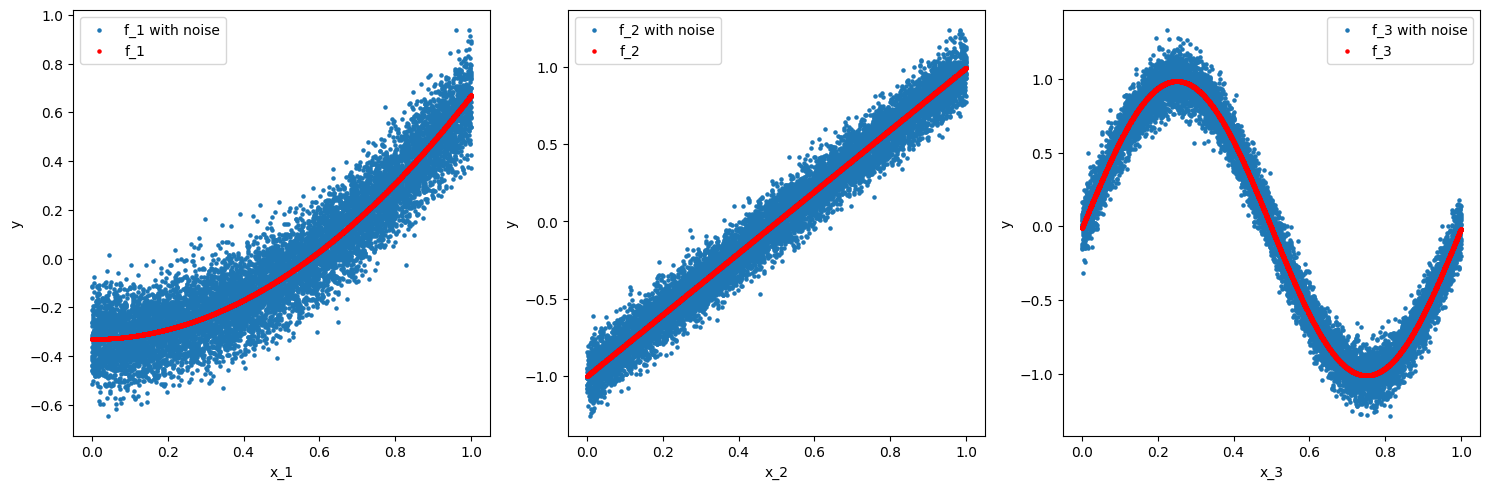

In [36]:
X_tabular, y_response, Y_response, y_noise = create_synthetic_table_normal_response(DATA_FUNCTIONS, noise_variance = 1e-2, n_datapoints= 10000, x_min= 0, x_max= 1, equally_spaced = False)

In [37]:
X_tabular = (X_tabular- X_tabular.mean(axis = 0)) / X_tabular.std(axis=0)

In [ ]:
r_vals = average_red_value_batch(images)

In [ ]:
# use a linear function of how much the image x-position varies between the upper left hand-side corner and the upper right-hand-side corner

min_xvals = torch.min(r_vals)
max_xvals = torch.max(r_vals)


standardize_x_vals = lambda x: ((x-min_xvals) / (max_xvals - min_xvals))   #scale position values between 0 and 1


f_img_raw = lambda x: torch.sin(2*torch.pi*x)
f_img = lambda x: f_img_raw(standardize_x_vals(x))

In [ ]:
max_xvals

tensor(0.9999)

In [ ]:
def f_img_raw(x):
  try:
    return np.sin(2*np.pi*x)
  except:
    return torch.sin(2*torch.pi*x)

f_img = lambda x: f_img_raw(standardize_x_vals(x))

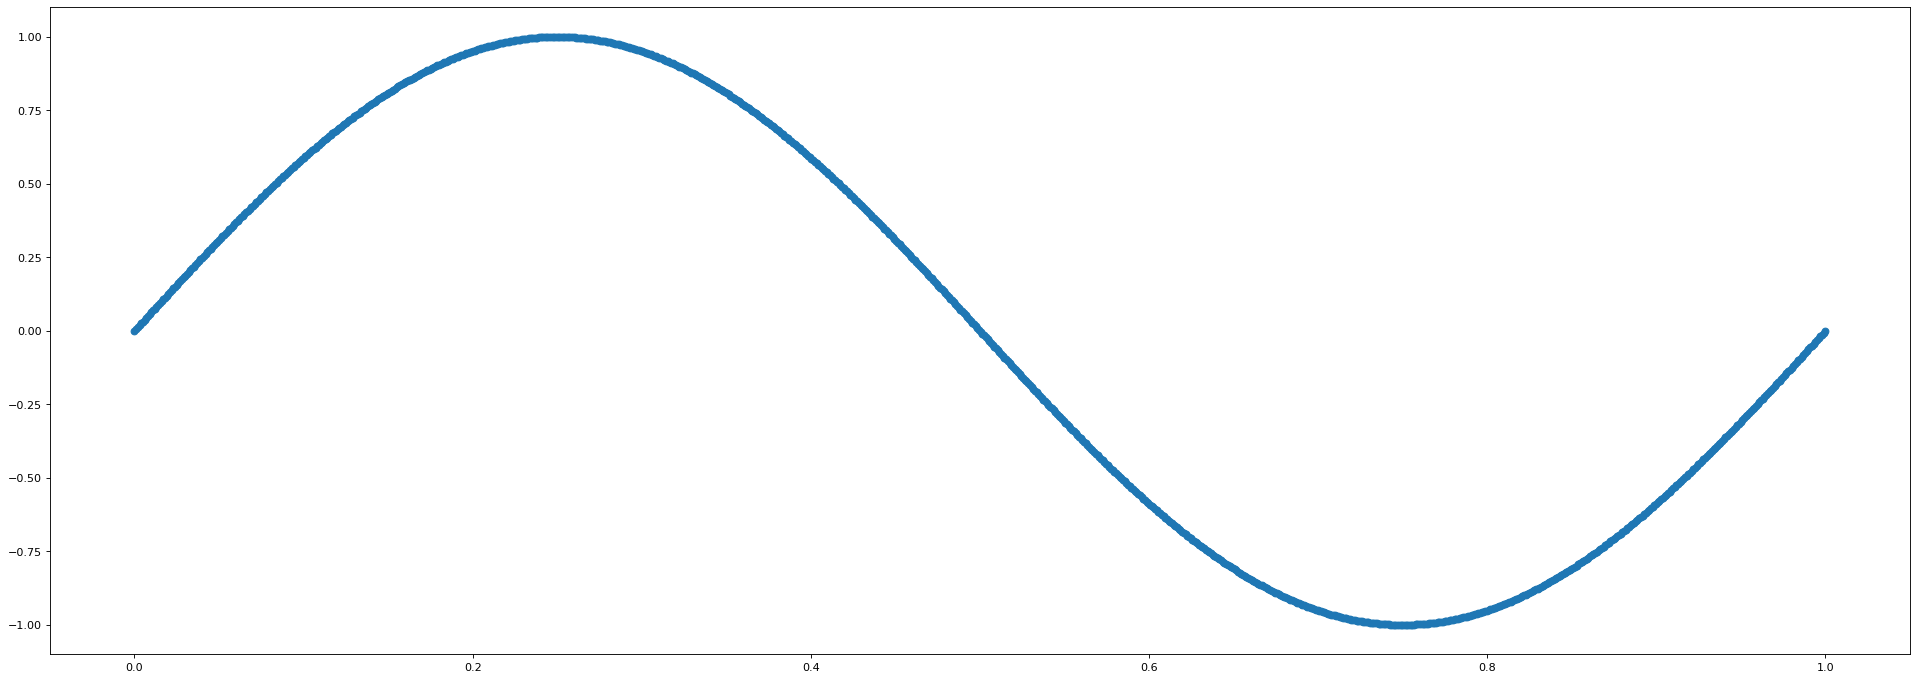

In [ ]:
min_img_x = standardize_x_vals(r_vals).min().numpy()
max_img_x = standardize_x_vals(r_vals).max().numpy()
x_test_img = np.linspace(min_img_x, max_img_x, 1000)

y_test_img = f_img_raw(torch.tensor(x_test_img)).numpy()
y_test_img = y_test_img - np.mean(y_test_img)

from matplotlib.pyplot import figure

figure(figsize=(30, 10.5), dpi=80)

plt.scatter(x_test_img, y_test_img)

In [ ]:
img_effect = f_img(r_vals).numpy()
img_effect = (img_effect - np.mean(img_effect))

In [ ]:
y_response = y_response + img_effect

In [ ]:
np.mean(y_response)

In [ ]:
X_tabular[:,2].mean()

-9.459100169806333e-16

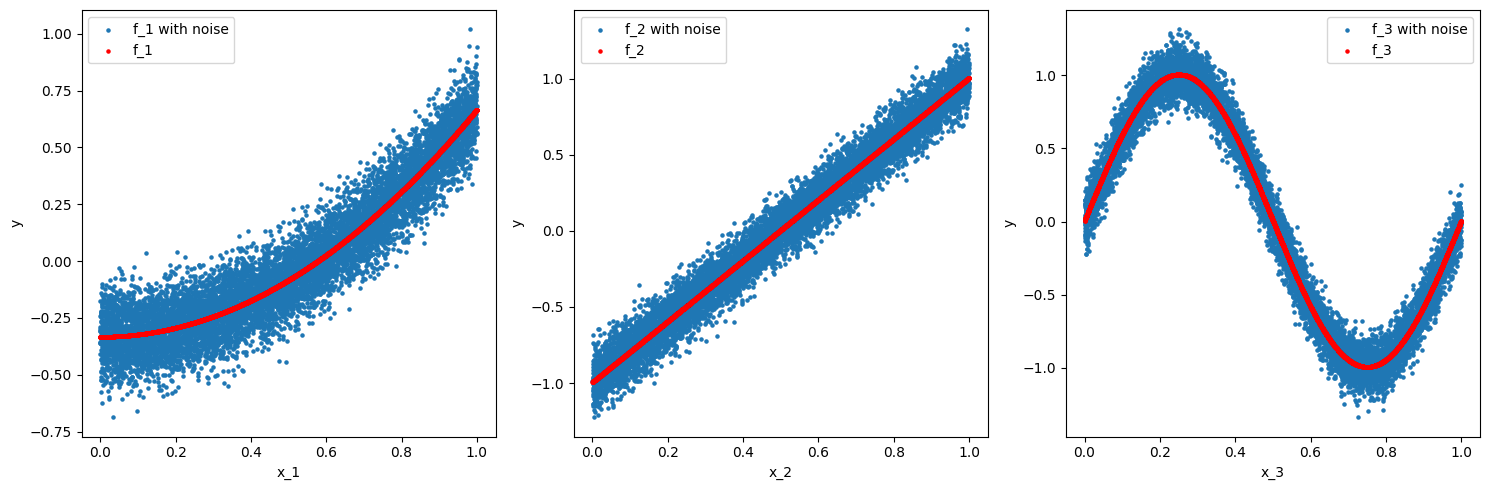

In [38]:
X_tabular_test, y_response_test, Y_response_test, y_noise_test = create_synthetic_table_normal_response(DATA_FUNCTIONS, noise_variance = 1e-2, n_datapoints= 10000, x_min= 0, x_max= 1, equally_spaced = False)

In [39]:
X_tabular_test_norm = (X_tabular_test- X_tabular_test.mean(axis = 0)) / X_tabular_test.std(axis=0)

In [40]:
class CustomDataset_features(torch.utils.data.Dataset):
    """Face Landmarks dataset."""
    def __init__(self, feature_ten, label_ten, transforms=None):

        self.label_ten = label_ten
        self.feature_ten = feature_ten
        self.transforms = transforms

        assert len(label_ten) ==  len(feature_ten), "img_ten and and feature_ten and label ten must have equal size"

    def __len__(self):
      return len(self.feature_ten)

    def __getitem__(self, idx):
      feat = self.feature_ten[idx]
      y = self.label_ten[idx]

      return feat, y

In [41]:
def train_test_split_features(features, targets, train_frac, val_frac, batch_size, transforms_val_test = None, transforms_train = None):

    tot_len = len(features)

    train_max_idx = int(tot_len*train_frac)
    val_max_idx = int(tot_len*val_frac) + train_max_idx

    train_features = features[:train_max_idx]
    train_y = targets[:train_max_idx]

    val_features = features[train_max_idx:val_max_idx]
    val_y = targets[train_max_idx:val_max_idx]

    test_features = features[val_max_idx:]
    test_y = targets[val_max_idx:]

    train_set = CustomDataset_features(train_features, train_y)
    val_set = CustomDataset_features(val_features, val_y)
    test_set = CustomDataset_features(test_features, test_y)

    train_loader = torch.utils.data.DataLoader(train_set, batch_size = batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_set, batch_size = batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size = batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [42]:
train_loader, val_loader, test_loader = train_test_split_features(features = torch.tensor(X_tabular).float(),
                                                         targets = torch.tensor(y_response).float(),
                                                         train_frac = 0.7,
                                                         val_frac = 0.2,
                                                         batch_size = 256)

In [ ]:
class CustomDataset_img_features(torch.utils.data.Dataset):
    """Face Landmarks dataset."""
    def __init__(self, img_ten, feature_ten, label_ten, transforms=None):

        self.img_ten = img_ten
        self.label_ten = label_ten
        self.feature_ten = feature_ten
        self.transforms = transforms

        assert len(img_ten) == len(label_ten) ==  len(feature_ten), "img_ten and and feature_ten and label ten must have equal size"
    def __len__(self):
      return len(self.img_ten)

    def __getitem__(self, idx):
      x = self.img_ten[idx]
      feat = self.feature_ten[idx]
      y = self.label_ten[idx]

      if not self.transforms == None:
        x = self.transforms(x)

      return x, feat, y

    def set_transforms(self, transforms):
      self.transforms = transforms

In [ ]:
def train_test_split_features_images(features, images, targets, train_frac, val_frac, batch_size, transforms_val_test = None, transforms_train = None):
    tot_len = len(features)

    train_max_idx = int(tot_len*train_frac)
    val_max_idx = int(tot_len*val_frac) + train_max_idx

    train_features = features[:train_max_idx]
    train_images = images[:train_max_idx]
    train_y = targets[:train_max_idx]

    val_features = features[train_max_idx:val_max_idx]
    val_images = images[train_max_idx:val_max_idx]
    val_y = targets[train_max_idx:val_max_idx]

    test_features = features[val_max_idx:]
    test_images = images[val_max_idx:]
    test_y = targets[val_max_idx:]

    train_set = CustomDataset_img_features(train_images, train_features, train_y, transforms = transforms_train)
    val_set = CustomDataset_img_features(val_images, val_features, val_y, transforms = transforms_val_test)
    test_set = CustomDataset_img_features(test_images, test_features, test_y, transforms = transforms_val_test)

    train_loader = torch.utils.data.DataLoader(train_set, batch_size = batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_set, batch_size = batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size = batch_size, shuffle=True)

    return train_loader, val_loader, test_loader

In [ ]:
train_loader_img, val_loader_img, test_loader_img = train_test_split_features_images(images = images,
                                                         features = torch.tensor(X_tabular).float(),
                                                         targets = torch.tensor(y_response).float(),
                                                         train_frac = 0.7,
                                                         val_frac = 0.2,
                                                         batch_size = 256)

NameError: name 'train_test_split_features_images' is not defined

#


# Modules

In [16]:
class BayesFeature(nn.Module):
  def __init__(self, hid_dim=[], dropout_rate = 0.0, prior_scale= .1, activation_function = nn.LeakyReLU()):
    super(BayesFeature, self).__init__()

    self.activation = activation_function

    self.layer_sizes = [1] + hid_dim + [1]

    self.layers = nn.ModuleList([
        BayesLinear(self.layer_sizes[idx - 1], self.layer_sizes[idx], weight_prior_sigma = prior_scale) for idx in
                      range(1, len(self.layer_sizes))])

    self.dropout = torch.nn.Dropout(p = dropout_rate)

  def forward(self, x):

    kl_sum = 0

    out, kl = self.layers[0](x)
    kl_sum += kl
    out = self.activation(out)

    for layer in self.layers[1:-1]:
      out, kl = layer(out)
      kl_sum += kl
      out = self.activation(out)
      out = self.dropout(out)

    out, kl = self.layers[-1](out)
    kl_sum += kl

    return out, kl_sum

class BayesNAM(nn.Module):
  def __init__(self,
                n_features,   # number of neurons in first layer
                hidden_units = [],  # tuple of numbers of hidden units
                dropout_rate = 0.0,
                feature_dropout_rate = 0.0,
                activation = nn.LeakyReLU(),
                prior_scale = .1,
                return_output_lis = False
                ):
      super().__init__()


      self.samples = {'bias' : None}

      #self.shallow_units = shallow_units
      self.hidden_units = hidden_units
      self.activation = activation

      self.feature_dropout_rate = feature_dropout_rate

      self.feature_dropout = torch.nn.Dropout(p=self.feature_dropout_rate)

      self.n_features = n_features
      self.return_output_lis = return_output_lis

      self.feature_nns = nn.ModuleList([
          BayesFeature(hid_dim = hidden_units, dropout_rate= dropout_rate, prior_scale= prior_scale, activation_function = activation)
          for i in range(n_features)
      ])

      self.bias = nn.Parameter(torch.zeros(1))   #does the bias need a prior? probably yes

      self.bias_prior_mu = 0.
      self.bias_prior_sigma = .1
      self.bias_mean = Parameter(torch.rand(1) -0.5) # intialize bias mean if given
      self.lbias_sigma = Parameter(torch.log(prior_scale* torch.ones(1)))


  def kl_div(self, mu_q, sigma_q, mu_p, sigma_p):
        kl = sigma_p - sigma_q + (torch.exp(sigma_q)**2 + (mu_q - mu_p)**2) / (2 * math.exp(sigma_p)**2) - 0.5  # Kullback Leibler divergence for two normals

        return kl.mean()

  def getSampledBias(self):
        return self.samples['bias']


  def forward(self, f):

    #eta = self.bias
    output_lis = []
    kl_total = 0

    for feature, mod in zip(f.T, self.feature_nns):

      feature = feature.unsqueeze(-1)
      ri, kl = mod(feature)
      kl_total += kl
      output_lis.append(ri)


    self.samples['bias'] = self.bias_mean + torch.exp(self.lbias_sigma) * torch.randn_like(self.lbias_sigma)
    kl_total += self.kl_div(self.bias_mean, self.lbias_sigma, self.bias_prior_mu, self.bias_prior_sigma)

    if self.return_output_lis:
      return output_lis, kl_total

    else:
      conc_out = torch.cat(output_lis, dim=-1)
      dropout_out = self.feature_dropout(conc_out)
      out = torch.sum(dropout_out, dim=-1) + self.bias  #+ self.samples['bias'] #

      #out = out_1 + out_2 + out_3 + self.bias

      return out, kl_total


In [17]:
class BayesSkipBlock(nn.Module):
   def __init__(self, in_features, out_features, prior_scale = 0.1):
    super(BayesSkipBlock, self).__init__()


    self.linear_in = BayesLinear(in_features = in_features, out_features = in_features, weight_prior_sigma = prior_scale)
    self.linear_out = BayesLinear(in_features = in_features, out_features = in_features, weight_prior_sigma = prior_scale)

    self.act = torch.nn.LeakyReLU()

    self.bn1 = nn.BatchNorm1d(50, affine = True)
    self.bn2 = nn.BatchNorm1d(out_features, affine = True)


   def forward(self, x):

    kl_sum = 0
    x0 = x

    x, kl = self.linear_in(x)
    kl_sum += kl
    x = self.bn1(x)
    x = self.act(x)

    x, kl = self.linear_out(x)
    kl_sum += kl
    x = self.bn2(x)

    x = x0 + x

    x = self.act(x)

    return x, kl_sum




class BayesResFeature(nn.Module):
  def __init__(self, hid_dim=[50,100,100,50], dropout_rate = 0.0, prior_scale= .1, activation_function = nn.LeakyReLU()):
    super(BayesResFeature, self).__init__()

    self.activation = activation_function

    self.input_layer = BayesLinear(1, hid_dim[0])

    self.layers = nn.ModuleList([
        BayesSkipBlock(hid_dim[0], hid_dim[0], prior_scale = prior_scale) for idx in
                      range(1, len(hid_dim))])

    self.output_layer = BayesLinear(hid_dim[0], 1)

    self.dropout = torch.nn.Dropout(p = dropout_rate)

    self.bn1 = nn.BatchNorm1d(hid_dim[0], affine = True)

  def forward(self, x):

    kl_sum = 0

    out, kl = self.input_layer(x)
    kl_sum += kl
    out = self.bn1(out)
    out = self.activation(out)
    out = self.dropout(out)

    for layer in self.layers:
      out, kl = layer(out)
      kl_sum += kl

    out, kl = self.output_layer(out)
    kl_sum += kl

    return out, kl_sum



class BayesRes(nn.Module):
  def __init__(self,
                n_features,   # number of neurons in first layer
                hidden_units = [50,100,100,50],  # tuple of numbers of hidden units
                dropout_rate = 0.0,
                feature_dropout_rate = 0.0,
                activation = nn.LeakyReLU(),
                prior_scale = .1,
                return_output_lis = False
                ):
      super().__init__()


      self.samples = {'bias' : None}

      #self.shallow_units = shallow_units
      self.hidden_units = hidden_units
      self.activation = activation

      self.feature_dropout_rate = feature_dropout_rate

      self.feature_dropout = torch.nn.Dropout(p=self.feature_dropout_rate)

      self.n_features = n_features
      self.return_output_lis = return_output_lis

      self.feature_nns = nn.ModuleList([
          BayesResFeature(hid_dim = hidden_units, dropout_rate= dropout_rate, prior_scale= prior_scale, activation_function = activation)
          for i in range(n_features)
      ])

      self.bias = nn.Parameter(torch.zeros(1))   #does the bias need a prior? probably yes

      self.bias_prior_mu = 0.
      self.bias_prior_sigma = .1
      self.bias_mean = Parameter(torch.rand(1) -0.5) # intialize bias mean if given
      self.lbias_sigma = Parameter(torch.log(prior_scale* torch.ones(1)))


  def kl_div(self, mu_q, sigma_q, mu_p, sigma_p):
        kl = sigma_p - sigma_q + (torch.exp(sigma_q)**2 + (mu_q - mu_p)**2) / (2 * math.exp(sigma_p)**2) - 0.5  # Kullback Leibler divergence for two normals

        return kl.mean()

  def getSampledBias(self):
        return self.samples['bias']


  def forward(self, f):

    #eta = self.bias
    output_lis = []
    kl_total = 0

    for feature, mod in zip(f.T, self.feature_nns):

      feature = feature.unsqueeze(-1)
      ri, kl = mod(feature)
      kl_total += kl
      output_lis.append(ri)

    #self.samples['bias'] = self.bias_mean + torch.exp(self.lbias_sigma) * torch.randn_like(self.lbias_sigma)
    #kl_total += self.kl_div(self.bias_mean, self.lbias_sigma, self.bias_prior_mu, self.bias_prior_sigma)


    conc_out = torch.cat(output_lis, dim=-1)
    dropout_out = self.feature_dropout(conc_out)
    out = torch.sum(dropout_out, dim=-1) + self.bias #+ self.samples['bias']


    return out, kl_total

In [18]:
class BayesImageNAM(torch.nn.Module):
  def __init__(self,
                pretrained_encoder,
                bayes_mlp, #BayesResFeature
                bayes_feat_nam,
                ):
      super().__init__()

      self.pretrained_encoder = pretrained_encoder
      self.bayes_mlp = bayes_mlp
      self.bayes_feat_nam = bayes_feat_nam
      self.bayes_feat_nam.return_output_lis = True

  def forward(self, image, features):

    total_kl = 0

    output_lis_nam, kl = self.bayes_feat_nam(features)

    total_kl += kl

    res_cnn = self.pretrained_encoder.encode(image)
    res_cnn, kl = self.bayes_mlp(res_cnn)

    total_kl += kl

    output_lis = output_lis_nam + [res_cnn]
    output_lis = torch.cat(output_lis, dim=-1)

    output_lis = self.bayes_feat_nam.feature_dropout(output_lis)
    out = torch.sum(output_lis, dim=-1) + self.bayes_feat_nam.bias
    return out, total_kl

# Helpers


In [71]:
def validate(model, val_loader, loss_fun, kl_weight, n_samples):

    val_loss = []

    model.eval()

    with torch.no_grad():
        for i, batch in enumerate(val_loader):

            input, target = batch

            target = target.to(device)
            input = input.to(device)

            output = []
            kl_div = []

            for sample in range(n_samples):
                out, kl = model(input)
                output.append(out)
                kl_div.append(kl)

            mean_pred = torch.mean(torch.stack(output), dim = 0)
            kl_loss = torch.mean(torch.stack(kl_div), dim = 0)
            scaled_kl = kl_loss * kl_weight
            log_lik_loss = loss_fun(mean_pred.squeeze(-1), target)
            loss = log_lik_loss + scaled_kl
            val_loss.append(loss.cpu())

        mean_loss = np.mean(np.array(val_loss))

    return mean_loss


def train(model, optimizer, loss_fun, trainset, valset, device, n_epochs, n_samples, kl_weight = 0.1, early_stopping = True, n_epochs_early_stopping = 50, save_path = None, print_mod = 1):

    loss_lis = []
    overall_loss = []
    val_loss = []

    if early_stopping == True:
      n_early_stopping = n_epochs_early_stopping
      past_val_losses = []

    model = model.to(device)

    for epoch in range(n_epochs):

        for i, batch in enumerate(trainset):

            x, y = batch
            x = x.to(device)
            y = y.to(device)

            output = []
            kl_div = []

            for _ in range(n_samples):
                out, kl = model(x)
                output.append(out)
                kl_div.append(kl)


            mean_pred = torch.mean(torch.stack(output), dim = 0)
            kl_loss = torch.mean(torch.stack(kl_div), dim = 0)

            #print(kl_loss)

            mean_pred = mean_pred.squeeze(-1)


            loss = loss_fun(mean_pred, y)
            scaled_kl = kl_loss * kl_weight #/ 256
            loss += scaled_kl  #ELBO Loss add if loos_fun is negative log_likelihood

            #loss = loss_fun(out, y)
            #loss += kl * 0.1     # Why does this improve training so much? kl / batch_size and add sampling again


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_lis.append(loss.cpu().detach())

        if epoch % print_mod == 0:

            mean_loss = np.mean(np.array(loss_lis))
            overall_loss += mean_loss
            loss_lis = []

            validation_loss = validate(model = model, val_loader = valset, loss_fun = loss_fun, kl_weight = kl_weight, n_samples = n_samples)

            val_loss.append(validation_loss)


            print(f'Epoch nr {epoch}: mean_train_loss = {mean_loss}, mean_valid_loss = {validation_loss}')



            if early_stopping:

              if len(past_val_losses) == 0 or validation_loss < min(past_val_losses):
                print("save model")
                torch.save(model.state_dict(), save_path)

              if len(past_val_losses) >= n_early_stopping:
                if validation_loss > max(past_val_losses):
                  print(f"Early stopping because the median validation loss has not decreased since the last {n_early_stopping} epochs")
                  return overall_loss
                else:
                  past_val_losses = past_val_losses[1:] + [validation_loss]
              else:
                past_val_losses = past_val_losses + [validation_loss]

    print(kl_loss)

    return overall_loss



def sample_features(model, n_features, n_samples, x_data, y_data, function_list):

  mean_outputs = np.zeros((len(x_data), n_features))
  standard_variations = np.zeros((len(x_data), n_features))

  bias_mean = model.bias_mean
  bias_log_scale = model.lbias_sigma
  #bias = model.bias.item()

  max_fun = lambda x: np.quantile(x, q = 1)
  min_fun = lambda x: np.quantile(x, q = 0)


   # sample individual features
  for i in range(n_features):

    feat_model = model.feature_nns[i]

    x_vals_compute = x_data[:, i]

    #valid_idx = (x_vals_compute >= min_fun(x_vals_compute)) & (x_vals_compute <= max_fun(x_vals_compute))

    #x_vals_compute = x_vals_compute[valid_idx]

    min_compute = min(x_vals_compute)
    max_compute = max(x_vals_compute)
    range_compute = torch.linspace(min_compute, max_compute, len(x_vals_compute))

    with torch.no_grad():

      model_input = range_compute.to(device).reshape(-1,1).float()

      output_mc = []

      for _ in range(n_samples):
        #bias = torch.normal(bias_mean, torch.exp(bias_log_scale))
        out, _ = feat_model.forward(model_input)
        out = out #+ bias
        output_mc.append(out)

      output = torch.stack(output_mc)

      mean_pred_batch = torch.mean(output, dim = 0)
      mean_pred_batch = mean_pred_batch - torch.mean(mean_pred_batch)
      std = torch.sqrt(torch.var(output, dim = 0))
      mean_outputs[:, i] = mean_pred_batch.squeeze().cpu().numpy()
      standard_variations[:, i] = std.squeeze().cpu().numpy()


  plus_error = [mean_outputs[:,i] + 2 * standard_variations[:,i] for i in range(n_features)]
  minus_error = [mean_outputs[:,i] - 2 * standard_variations[:,i] for i in range(n_features)]

  with sns.axes_style('whitegrid'):

    fig, axes = plt.subplots(n_features, 1, figsize=(7, 12))

    for i in range(n_features):

      axes[i].set_xlabel(r'$x$')
      axes[i].set_ylabel(r'$y$')
      axes[i].scatter(x_data[:, i], y_data[i,:], color='k', s=2, alpha=0.7)
      axes[i].plot(range_compute, mean_outputs[:,i], 'r-', linewidth=3, label='Mean')

      # Add error bands
      axes[i].fill_between(range_compute, minus_error[i], plus_error[i],
                          color='r', alpha=0.2, label='±2σ')
      # Or plot error lines instead:
      # axes[i].plot(range_compute, plus_error[i], 'r--', linewidth=1, alpha=0.5)
      # axes[i].plot(range_compute, minus_error[i], 'r--', linewidth=1, alpha=0.5)

      axes[i].set_title(f'Prediction {i+1}')
      axes[i].grid(True, alpha=0.3)
      axes[i].legend(loc='best')


    plt.tight_layout()

    #plt.tight_layout()
    plt.show()


  return mean_outputs, standard_variations



In [ ]:
axes[i].set_xlabel(r'$x$')
        axes[i].set_ylabel(r'$y$')
        axes[i].scatter(x_data[:, i], y_data[i,:], color='deeppink', label='True Function')
        axes[i].plot(range_compute, mean_outputs[:,i], "-", color= goeblue, label='Mean')
        axes[i].plot(range_compute, plus_error[i], "-", color=midblue, lw=1, label='2$\sigma$')
        axes[i].plot(range_compute, minus_error[i], "-", color=midblue, lw=1)

        axes[i].grid(linestyle=':')

        # Add error bands
        #axes[i].fill_between(range_compute, minus_error[i], plus_error[i],
        #                    color='r', alpha=0.2, label='±2σ')
        # Or plot error lines instead:
        # axes[i].plot(range_compute, plus_error[i], 'r--', linewidth=1, alpha=0.5)
        # axes[i].plot(range_compute, minus_error[i], 'r--', linewidth=1, alpha=0.5)

        axes[i].set_title(f'Prediction {i+1}')
        #axes[i].grid(True, alpha=0.3)
        #axes[i].legend(loc='best')

    plt.legend(ncol=2)

In [ ]:
f1 = lambda x: x**2
f2 = lambda x: 2*x # np.sin(2*x)
f3 = lambda x: np.sin(2*np.pi*x) # x**3 - x**2


DATA_FUNCTIONS = [f1, f2, f3]
N_FEATURES_TABULAR = len(DATA_FUNCTIONS)

In [62]:
def validate_images(model, val_loader, loss_fun, kl_weight, n_samples):

    val_loss = []

    model.eval()

    with torch.no_grad():
        for i, batch in enumerate(val_loader):

            images, features, target = batch

            images = images.to(device)
            target = target.to(device)
            features = features.to(device)

            output = []
            kl_div = []

            for sample in range(n_samples):
                out, kl = model(images, features)
                output.append(out)
                kl_div.append(kl)

            mean_pred = torch.mean(torch.stack(output), dim = 0)
            kl_loss = torch.mean(torch.stack(kl_div), dim = 0)
            scaled_kl = kl_loss * kl_weight
            log_lik_loss = loss_fun(mean_pred.squeeze(-1), target)
            loss = log_lik_loss + scaled_kl
            val_loss.append(loss.cpu())

        mean_loss = np.mean(np.array(val_loss))

    return mean_loss


def train_images(model, optimizer, loss_fun, trainset, valset, device, n_epochs, n_samples, kl_weight = 0.1, early_stopping = True, n_epochs_early_stopping = 50, save_path = None, print_mod = 1):

    loss_lis = []
    overall_loss = []
    val_loss = []

    if early_stopping == True:
      n_early_stopping = n_epochs_early_stopping
      past_val_losses = []

    model = model.to(device)

    for epoch in range(n_epochs):

        for i, batch in enumerate(trainset):

            images, features, target = batch

            images = images.to(device)
            target = target.to(device)
            features = features.to(device)

            output = []
            kl_div = []

            for _ in range(n_samples):
                out, kl = model(images, features)
                output.append(out)
                kl_div.append(kl)


            mean_pred = torch.mean(torch.stack(output), dim = 0)
            kl_loss = torch.mean(torch.stack(kl_div), dim = 0)

            #print(kl_loss)

            mean_pred = mean_pred.squeeze(-1)


            loss = loss_fun(mean_pred, y)
            scaled_kl = kl_loss * kl_weight
            loss += scaled_kl  #ELBO Loss add if loos_fun is negative log_likelihood

            #loss = loss_fun(out, y)
            #loss += kl * 0.1     # Why does this improve training so much? kl / batch_size and add sampling again


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_lis.append(loss.cpu().detach())

        if epoch % print_mod == 0:

            mean_loss = np.mean(np.array(loss_lis))
            overall_loss += mean_loss
            loss_lis = []

            validation_loss = validate(model = model, val_loader = valset, loss_fun = loss_fun, kl_weight = kl_weight, n_samples = n_samples)

            val_loss.append(validation_loss)


            print(f'Epoch nr {epoch}: mean_train_loss = {mean_loss}, mean_valid_loss = {validation_loss}')



            if early_stopping:

              if len(past_val_losses) == 0 or validation_loss < min(past_val_losses):
                print("save model")
                torch.save(model.state_dict(), save_path)

              if len(past_val_losses) >= n_early_stopping:
                if validation_loss > max(past_val_losses):
                  print(f"Early stopping because the median validation loss has not decreased since the last {n_early_stopping} epochs")
                  return overall_loss
                else:
                  past_val_losses = past_val_losses[1:] + [validation_loss]
              else:
                past_val_losses = past_val_losses + [validation_loss]

    print(kl_loss)

    return overall_loss



def sample_features_images(model, n_features, n_samples, x_data, y_data):

  mean_outputs = np.zeros((len(x_data), n_features+1))
  standard_variations = np.zeros((len(x_data), n_features+1))

  bias_mean = model.bias_mean
  bias_log_scale = model.lbias_sigma
  #bias = model.bias.item()

  max_fun = lambda x: np.quantile(x, q = 1)
  min_fun = lambda x: np.quantile(x, q = 0)


   # sample individual features
  for i in range(n_features+1):

    if i > n_features:

      feat_model = model.bayes_mlp(model_input)

      x_vals_compute = x_data[:, i-1]

      #valid_idx = (x_vals_compute >= min_fun(x_vals_compute)) & (x_vals_compute <= max_fun(x_vals_compute))

      #x_vals_compute = x_vals_compute[valid_idx]

      min_compute = min(x_vals_compute)
      max_compute = max(x_vals_compute)
      range_compute = torch.linspace(min_compute, max_compute, len(x_vals_compute))

    else:

      feat_model = model.feature_nns[i]

      x_vals_compute = x_data[:, i]

      #valid_idx = (x_vals_compute >= min_fun(x_vals_compute)) & (x_vals_compute <= max_fun(x_vals_compute))

      #x_vals_compute = x_vals_compute[valid_idx]

      min_compute = min(x_vals_compute)
      max_compute = max(x_vals_compute)
      range_compute = torch.linspace(min_compute, max_compute, len(x_vals_compute))


    with torch.no_grad():

      model_input = range_compute.to(device).reshape(-1,1).float()

      output_mc = []

      for _ in range(n_samples):
        #bias = torch.normal(bias_mean, torch.exp(bias_log_scale))
        out, _ = feat_model.forward(model_input)
        out = out #+ bias
        output_mc.append(out)

      output = torch.stack(output_mc)

      mean_pred_batch = torch.mean(output, dim = 0)
      std = torch.sqrt(torch.var(output, dim = 0))
      mean_outputs[:, i] = mean_pred_batch.squeeze().cpu().numpy()
      standard_variations[:, i] = std.squeeze().cpu().numpy()


  plus_error = [mean_outputs[:,i] + 2 * standard_variations[:,i] for i in range(n_features)]
  minus_error = [mean_outputs[:,i] - 2 * standard_variations[:,i] for i in range(n_features)]

  fig, axes = plt.subplots(n_features + 1, 1, figsize=(7, 9))

  for i in range(n_features+1):
      axes[i].set_xlabel(r'$x$')
      axes[i].set_ylabel(r'$y$')
      axes[i].scatter(x_data[:, i], y_data[i,:], color='k', s=2, alpha=0.7)
      axes[i].plot(range_compute, mean_outputs[:,i], 'r-', linewidth=3, label='Mean')

      # Add error bands
      axes[i].fill_between(range_compute, minus_error[i], plus_error[i],
                          color='r', alpha=0.2, label='±2σ')
      # Or plot error lines instead:
      # axes[i].plot(range_compute, plus_error[i], 'r--', linewidth=1, alpha=0.5)
      # axes[i].plot(range_compute, minus_error[i], 'r--', linewidth=1, alpha=0.5)

      axes[i].set_title(f'Prediction {i+1}')
      axes[i].grid(True, alpha=0.3)
      axes[i].legend(loc='best')


  plt.tight_layout()
  plt.show()


  return mean_outputs, standard_variations


# Normal Bayesian without images

In [72]:
test_two_feature = BayesNAM(n_features = 3, hidden_units = [30, 30, 30, 30], dropout_rate= 0.2, feature_dropout_rate= 0.5, prior_scale=0.1)

In [73]:
mse_loss_two = nn.MSELoss()
#optimizer_two = torch.optim.AdamW(test_two_feature.parameters(), lr=0.1, weight_decay=1e-3)
optimizer_two = torch.optim.Adam(test_two_feature.parameters(), lr=0.01)

In [74]:
model_save_name = 'model'
path_one = './checkpoint.pt'

try add kl weight term, reduce sampling, scaling inputs ( also from to -1 1) , change initialization from network, try dropout, feature dropout

In [75]:
com_loss = train(model = test_two_feature, optimizer = optimizer_two, loss_fun = mse_loss_two, trainset = train_loader, valset= val_loader, device = device, n_epochs = 100, n_samples= 1, kl_weight= 0.001, early_stopping = True, n_epochs_early_stopping = 50, save_path = path_one, print_mod = 10)

Epoch nr 0: mean_train_loss = 2.9938411712646484, mean_valid_loss = 1.0037479400634766
save model
Epoch nr 10: mean_train_loss = 0.4026896357536316, mean_valid_loss = 0.2865563631057739
save model
Epoch nr 20: mean_train_loss = 0.24089020490646362, mean_valid_loss = 0.16054311394691467
save model
Epoch nr 30: mean_train_loss = 0.1723020374774933, mean_valid_loss = 0.17725543677806854
Epoch nr 40: mean_train_loss = 0.15801365673542023, mean_valid_loss = 0.19326436519622803
Epoch nr 50: mean_train_loss = 0.14219693839550018, mean_valid_loss = 0.13320299983024597
save model
Epoch nr 60: mean_train_loss = 0.12489982694387436, mean_valid_loss = 0.1134566068649292
save model
Epoch nr 70: mean_train_loss = 0.1162000373005867, mean_valid_loss = 0.11414764076471329
Epoch nr 80: mean_train_loss = 0.10536841303110123, mean_valid_loss = 0.09180819988250732
save model
Epoch nr 90: mean_train_loss = 0.09714583307504654, mean_valid_loss = 0.09477511048316956
tensor(58.3192, device='cuda:0', grad_fn=<

In [76]:
torch.save(test_two_feature.state_dict(), path_one)

In [77]:
test_two_feature.load_state_dict(torch.load(path_one))

<All keys matched successfully>

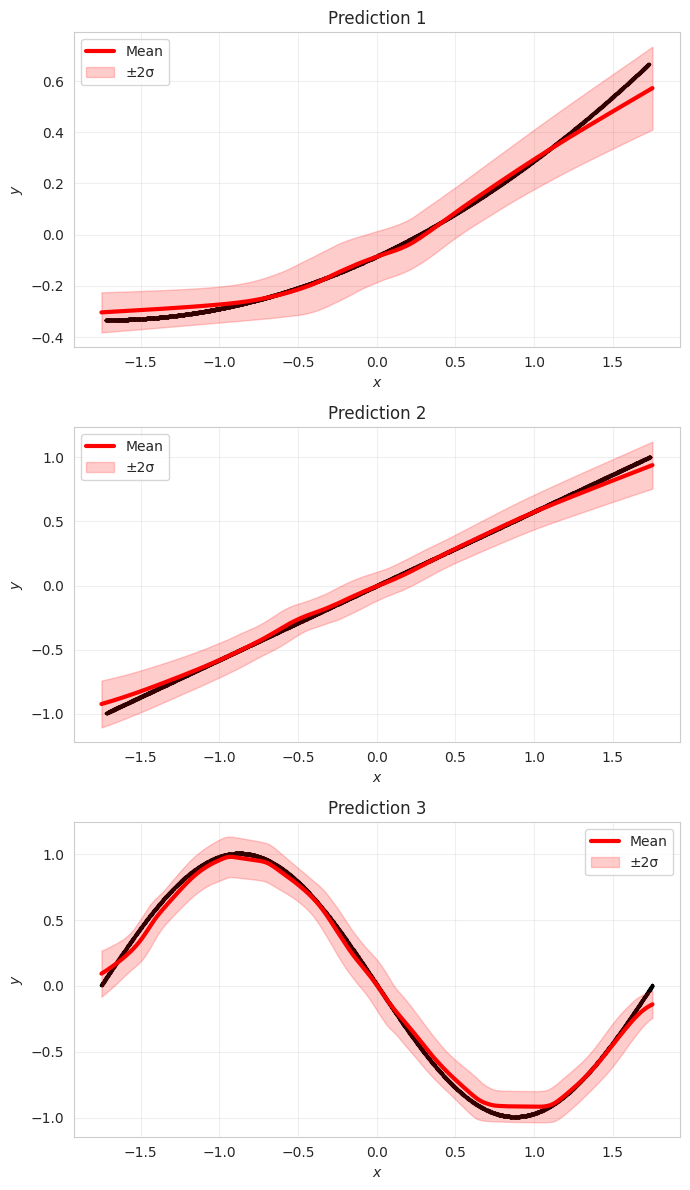

In [78]:
means, variations = sample_features(model = test_two_feature, n_features = 3, n_samples = 100, x_data = X_tabular_test_norm, y_data=Y_response_test, function_list=DATA_FUNCTIONS)

# Bayesian ResNet without Images

In [ ]:
res_feature = BayesRes(n_features = 3, dropout_rate= 0.0, feature_dropout_rate= 0.0, prior_scale=0.1)

In [ ]:
mse_loss_res = nn.MSELoss()
#optimizer_two = torch.optim.AdamW(test_two_feature.parameters(), lr=0.1, weight_decay=1e-3)
optimizer_res = torch.optim.Adam(res_feature.parameters(), lr=0.01)

In [ ]:
model_save_name_res = 'res_model'
path_res = './res_checkpoint.pt'

In [ ]:
res_loss = train(model = res_feature, optimizer = optimizer_res, loss_fun = mse_loss_res, trainset = train_loader, valset= val_loader, device = device, n_epochs = 300, n_samples= 1, kl_weight= 0.01, early_stopping = True, n_epochs_early_stopping = 50, save_path = path_res, print_mod = 10)


Epoch nr 0: mean_train_loss = 35.476078033447266, mean_valid_loss = 114.8746337890625
save model
Epoch nr 10: mean_train_loss = 98.71168518066406, mean_valid_loss = 12.485679626464844
save model
Epoch nr 20: mean_train_loss = 16.88740348815918, mean_valid_loss = 7.385148048400879
save model
Epoch nr 30: mean_train_loss = 8.35146427154541, mean_valid_loss = 9.909993171691895
Epoch nr 40: mean_train_loss = 7.36558723449707, mean_valid_loss = 9.297142028808594
Epoch nr 50: mean_train_loss = 6.859801769256592, mean_valid_loss = 8.018133163452148
Epoch nr 60: mean_train_loss = 6.0420241355896, mean_valid_loss = 4.925158977508545
save model
Epoch nr 70: mean_train_loss = 5.705725193023682, mean_valid_loss = 5.182021141052246
Epoch nr 80: mean_train_loss = 6.475108623504639, mean_valid_loss = 9.52688217163086
Epoch nr 90: mean_train_loss = 4.492914199829102, mean_valid_loss = 4.964042663574219
Epoch nr 100: mean_train_loss = 3.9865198135375977, mean_valid_loss = 3.6652917861938477
save model


In [ ]:
torch.save(res_feature.state_dict(), path_res)

In [ ]:
res_feature.load_state_dict(torch.load(path_res))

<All keys matched successfully>

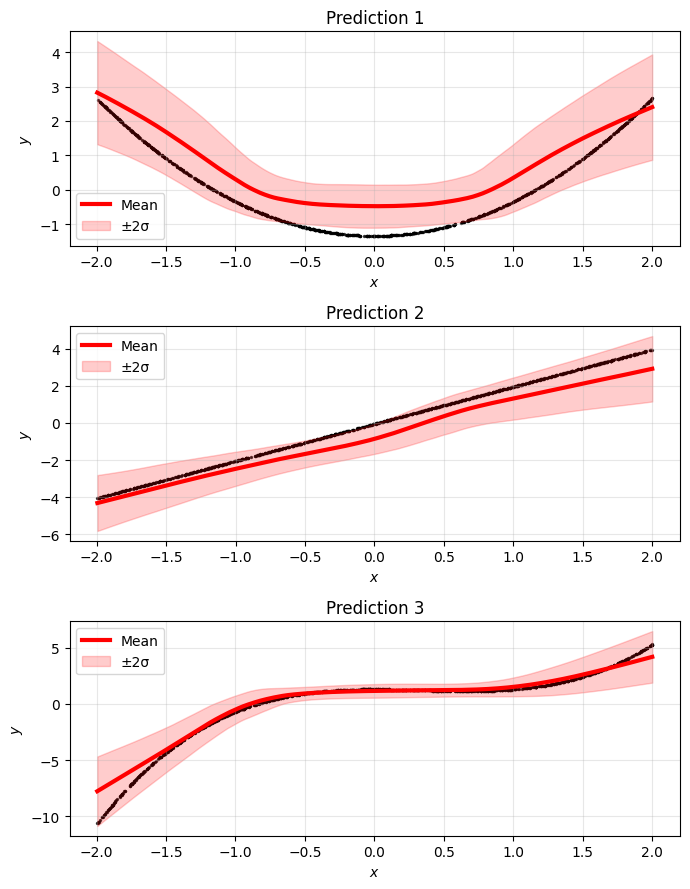

In [ ]:
means_res, variations_res = sample_features(model = res_feature, n_features = 3, n_samples = 100, x_data = X_tabular_test, y_data=Y_response_test)


# Normal Bayes with Images

In [ ]:
bayes_mlp = BayesResFeature()
bayes_nam = BayesNAM(n_features = 3, hidden_units = [50, 50, 50, 50], dropout_rate= 0.1, feature_dropout_rate= 0.5, prior_scale=0.1)

model_one = BayesImageNAM(pretrained_encoder, bayes_mlp, bayes_nam)

In [ ]:
mse_loss_one = nn.MSELoss()
#optimizer_two = torch.optim.AdamW(test_two_feature.parameters(), lr=0.1, weight_decay=1e-3)
optimizer_one = torch.optim.Adam(model_one.parameters(), lr=0.01)

In [ ]:
model_save_name_one = 'one_model'
path_res = './one_checkpoint.pt'

In [ ]:
one_loss = train(model = model_one, optimizer = optimizer_one, loss_fun = mse_loss_one, trainset = train_loader_img, valset= val_loader_img, device = device, n_epochs = 300, n_samples= 1, kl_weight= 0.01, early_stopping = True, n_epochs_early_stopping = 50, save_path = path_one, print_mod = 10)


In [ ]:
torch.save(model_one.state_dict(), path_one)

In [ ]:
model_one.load_state_dict(torch.load(path_one))

In [ ]:
means_one, variations_res = sample_features_images(model = model_one, n_features = 3, n_samples = 100, x_data = X_tabular_test, y_data=Y_response_test)
